In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier


======== WEEK 1 : DATA ENGINEERING ========
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0 

/tmp/ipykernel_647/722236706.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


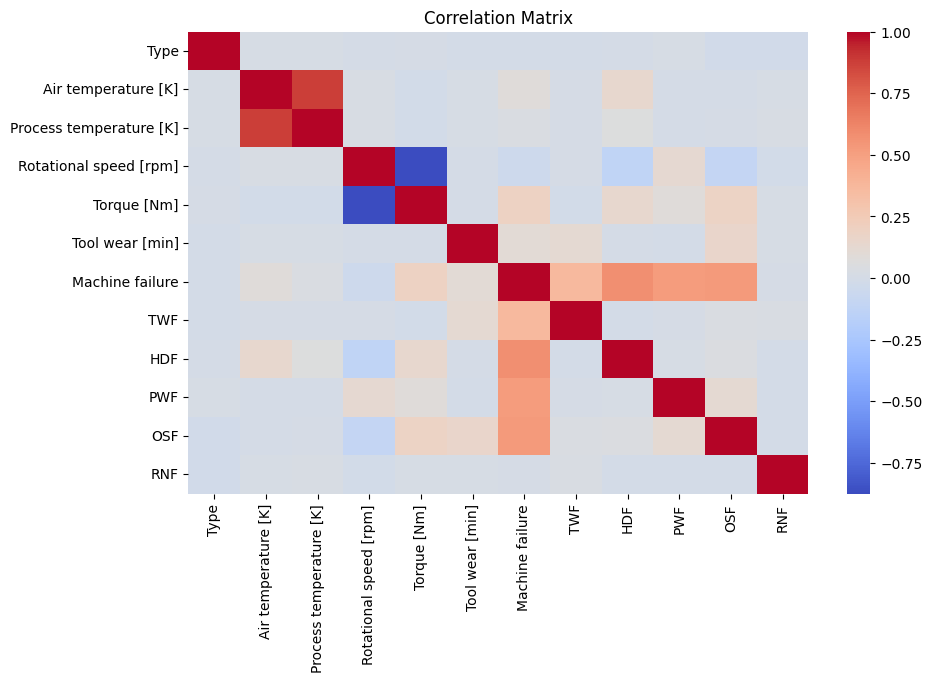

/tmp/ipykernel_647/722236706.py:34: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="bfill")


In [8]:

# WEEK 1 : DATA ENGINEERING
# Goal → Transform Raw Data into Modeling Dataset


print("======== WEEK 1 : DATA ENGINEERING ========")

# Load dataset
df = pd.read_csv("/content/ai4i2020.csv")

print(df.head())
print(df.info())

# Drop unnecessary columns
df.drop(columns=["UDI","Product ID"], errors="ignore", inplace=True)

# Encode categorical feature
if df["Type"].dtype == "object":
    df["Type"] = LabelEncoder().fit_transform(df["Type"])

# Handle missing values
df = df.fillna(method="ffill")

# Correlation Matrix
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


# -------- Temporal Feature Engineering (Rolling statistics) --------
df["Temp_roll_mean_3"] = df["Air temperature [K]"].rolling(3).mean()
df["Torque_roll_mean_3"] = df["Torque [Nm]"].rolling(3).mean()

df = df.fillna(method="bfill")

======== WEEK 2 : MODELING ========
Baseline F1 Score: 0.5866666666666667
Baseline Recall: 0.9705882352941176
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best RF Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost Parameters: {'subsample': 1, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1}

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1932
           1       0.68      0.96      0.79        68

    accuracy                           0.98      2000
   macro avg       0.84      0.97      0.89      2000
weighted avg       0.99      0.98      0.98      2000

F1 Score: 0.7926829268292683
Recall: 0.9558823529411765
ROC AUC: 0.9961256241627086


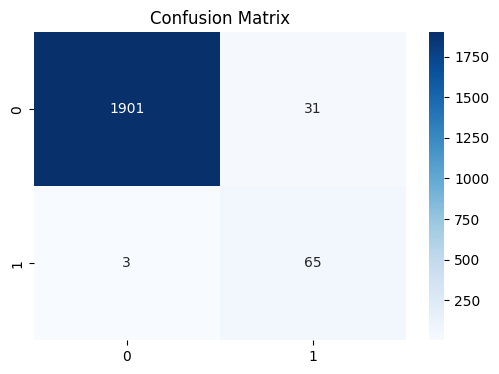

In [9]:


# WEEK 2 : MODELING & HYPERPARAMETER TUNING
# Goal → Beat baseline model
# =========================================================

print("======== WEEK 2 : MODELING ========")

# Features & Target
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]

# Sanitize column names for XGBoost
X.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X.columns]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Handle imbalance
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# -----------------------------
# Baseline Model
# Logistic Regression
# -----------------------------

baseline = LogisticRegression(max_iter=2000)

baseline.fit(X_res, y_res)

base_pred = baseline.predict(X_test)

print("Baseline F1 Score:", f1_score(y_test, base_pred))
print("Baseline Recall:", recall_score(y_test, base_pred))


# -----------------------------
# Random Forest Model
# -----------------------------

rf = RandomForestClassifier(random_state=42)

rf_params = {
    "n_estimators":[100,200,300],
    "max_depth":[4,6,8,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

rf_search = RandomizedSearchCV(
    rf,
    rf_params,
    n_iter=10,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)

rf_search.fit(X_res, y_res)

best_rf = rf_search.best_estimator_

print("Best RF Parameters:", rf_search.best_params_)


# -----------------------------
# XGBOOST MODEL (Production model)
# -----------------------------

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_params = {
    "n_estimators":[200,300,400],
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.05,0.1],
    "subsample":[0.7,0.8,1]
}

xgb_search = RandomizedSearchCV(
    xgb,
    xgb_params,
    n_iter=10,
    cv=3,
    scoring="f1",
    verbose=2,
    n_jobs=-1
)

xgb_search.fit(X_res, y_res)

best_model = xgb_search.best_estimator_

print("Best XGBoost Parameters:", xgb_search.best_params_)
# =========================================================
# MODEL EVALUATION
# =========================================================

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

print("\nClassification Report")
print(classification_report(y_test,y_pred))

print("F1 Score:", f1_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("ROC AUC:", roc_auc_score(y_test,y_prob))


# Confusion Matrix
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

======== WEEK 3 : EXPLAINABLE AI ========


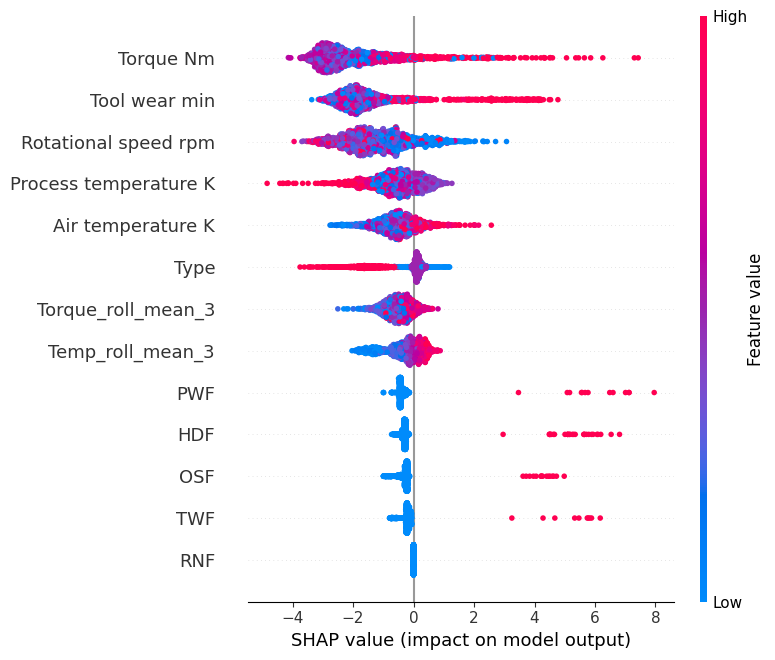

In [10]:
# =========================================================
# WEEK 3 : EXPLAINABLE AI (SHAP)
# Goal → Model Interpretability
# =========================================================

print("======== WEEK 3 : EXPLAINABLE AI ========")

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test)

# Summary Plot
shap.summary_plot(shap_values,X_test)

# Force Plot Example
sample = X_test.iloc[0]
shap.force_plot(explainer.expected_value, shap_values[0], sample)

In [11]:
# =========================================================
# WEEK 4 : DEPLOYMENT WRAPPER
# Goal → Model-as-a-Service
# =========================================================

print("======== WEEK 4 : MODEL DEPLOYMENT ========")

# Save trained model
joblib.dump(best_model,"factoryguard_model.pkl")

print("Model saved successfully")

======== WEEK 4 : MODEL DEPLOYMENT ========
Model saved successfully
